# Part 3: Advanced Text Processing – LDA and BERTopic Topic Modeling
Resources:

LDA:
- https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06
- https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
- https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/

BERTopic:
- https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly
- https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html

## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import spacy
from spacy import displacy

from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer

import pyLDAvis
import pyLDAvis.gensim_models

import os

nlp = spacy.load("en_core_web_sm")

/home/jovyan/.local/share/envs/sotu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

In [3]:
sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


## 3.1 LDA 

In this section I:
- Train an LDA model on the State of the Union speeches
- Inspect the learned topics and the topic distribution for the first speech
- Train a BERTopic model
- Inspect BERTopic topics and visualize the topic distribution for the first speech

In [4]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [5]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

This following section constructs the essential data structures required for topic modeling using Gensim’s LDA. First, the processed documents are converted into lists of tokens. A Dictionary object (id2word) is then created to map each unique token to a numerical ID, and filter_extremes removes extremely rare or overly common words to reduce noise. These tokens are then transformed into a bag-of-words format (corpus), which counts how many times each word appears in each document. Finally, the LDA model is instantiated with 18 topics, a fixed random seed (42) for reproducibility, and some other hyperparameters such as passes controlling training behavior.

In [6]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches
processed_docs_list = processed_docs.tolist()
id2word = Dictionary(processed_docs_list)
id2word.filter_extremes(no_below=5, no_above=0.5, keep_n=None)
corpus = [id2word.doc2bow(doc) for doc in processed_docs_list]

# train LDA model with 18 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=18,
    random_state=42,
    passes=10
)

This following loop iterates over the 18 learned topics and uses lda_model.show_topic() to extract the top 10 most probable words in each topic. These words are printed with their associated probabilities, illustrating which terms are most characteristic of each topic based on the model’s learned distributions.

In [7]:
# print the top 10 words for each topic

print("--- LDA Topics ---")
for topic_id in range(18):
    words = lda_model.show_topic(topic_id, topn=10)
    words_str = " + ".join([f'{prob:.3f}*"{term}"' for term, prob in words])
    print(f"Topic: {topic_id}")
    print(f"Words: {words_str}\n")

--- LDA Topics ---
Topic: 0
Words: 0.004*"cent" + 0.004*"june" + 0.004*"gold" + 0.003*"island" + 0.003*"silver" + 0.003*"bond" + 0.003*"method" + 0.003*"convention" + 0.003*"indian" + 0.003*"note"

Topic: 1
Words: 0.008*"depression" + 0.007*"program" + 0.007*"recovery" + 0.006*"budget" + 0.006*"unemployment" + 0.006*"loan" + 0.006*"activity" + 0.006*"farm" + 0.005*"emergency" + 0.005*"cent"

Topic: 2
Words: 0.008*"dictator" + 0.005*"expression" + 0.004*"british" + 0.004*"1914" + 0.003*"impressive" + 0.003*"actual" + 0.003*"revolution" + 0.003*"schedule" + 0.003*"continent" + 0.003*"partisanship"

Topic: 3
Words: 0.008*"forest" + 0.007*"corporation" + 0.005*"judge" + 0.005*"wrong" + 0.005*"interstate" + 0.004*"employee" + 0.003*"bureau" + 0.003*"body" + 0.003*"mountain" + 0.003*"island"

Topic: 4
Words: 0.017*"program" + 0.014*"soviet" + 0.009*"1980" + 0.009*"u.s." + 0.008*"area" + 0.007*"major" + 0.006*"goal" + 0.006*"commitment" + 0.006*"challenge" + 0.006*"nuclear"

Topic: 5
Words: 0

This code retrieves the topic mixture for the very first document in the corpus using the trained LDA model. The output `[(11, np.float32(0.99942815))]` suggests that Topic 11 overwhelmingly dominates the first speech, meaning the speech content aligns very strongly with the theme represented by Topic 11. This gives insight into the primary subject matter of that specific document.

In [10]:
# print the topic distribution for the first speech

first_doc_topics = lda_model.get_document_topics(corpus[0])
first_doc_topics

[(11, np.float32(0.99942815))]

The following cell prepares an interactive visualization summarizing all 18 topics. The bubble chart shows topics in a 2D space based on their distances, where each bubble size reflects how prevalent that topic is in the corpus. The visualization is also saved as an HTML file.

In [11]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(
    lda_model,
    corpus,
    id2word
)
save_path = "outputs/lda_vis.html"
pyLDAvis.save_html(lda_vis, save_path)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.124490 -0.021460       1        1  25.619188
6     -0.177721  0.042077       2        1  19.984267
5      0.215260  0.071386       3        1   9.900147
7      0.135347 -0.070053       4        1   9.756127
8     -0.048065 -0.119211       5        1   7.287460
17    -0.174387  0.056450       6        1   5.732110
13    -0.173280  0.057692       7        1   5.118594
9     -0.065566 -0.065617       8        1   3.674118
11     0.221114  0.096518       9        1   3.313298
12     0.108985 -0.107040      10        1   3.207489
4      0.170987 -0.059934      11        1   2.417467
3     -0.048335 -0.061174      12        1   1.963905
1      0.001805 -0.137938      13        1   1.024363
14     0.149811  0.117592      14        1   0.773020
15    -0.097709  0.071397      15        1   0.174831
2     -0.030759  0.033480      16        1   0.045783
10    -0.027617  0.048256      17        1   0.003916
16    -0.035383  0.047579      18        1   0.003916, topic_info=           Term         Freq        Total Category  logprob  loglift
509     program  1272.000000  1272.000000  Default  30.0000  30.0000
978      mexico   852.000000   852.000000  Default  29.0000  29.0000
31    americans   990.000000   990.000000  Default  28.0000  28.0000
5330    article   492.000000   492.000000  Default  27.0000  27.0000
666     tonight   666.000000   666.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
3221     method     0.007818   526.114119  Topic18  -7.4658  -0.9690
664       today     0.007947   576.827659  Topic18  -7.4494  -1.0447
1148    appoint     0.007382   419.010534  Topic18  -7.5231  -0.7987
31    americans     0.008294   990.533966  Topic18  -7.4067  -1.5426
2624       cent     0.007440   614.033642  Topic18  -7.5154  -1.1731

[1282 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
4847      4  0.881695  --the
4847      8  0.080154  --the
3170      1  0.132809   11th
3170      2  0.079685   11th
3170      6  0.292180   11th
...     ...       ...    ...
744       9  0.116609  young
744      10  0.003239  young
744      11  0.016196  young
744      12  0.009717  young
744      14  0.009717  young

[5615 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 6, 8, 9, 18, 14, 10, 12, 13, 5, 4, 2, 15, 16, 3, 11, 17])

## 3.2 BERTopic modeling

Next, I fit a BERTopic model with a minimum topic size of 3, remove
stopwords from the topic representations using a `CountVectorizer`, and inspect
the topics and their probabilities for the first speech.

This section prepares and fits a BERTopic model to the collection of speeches. The text column is first converted into a simple Python list (`docs`) so the model can process it. BERTopic is then initialized with a minimum topic size and probability calculation enabled, and `fit_transform()` is used to embed the documents, reduce their dimensionality, and cluster them into topics. After that, a `CountVectorizer` is created with English stopwords removed to clean up the topic representations. Finally, `update_topics()` is applied to refine the topics using this cleaned vocabulary, improving the overall quality and interpretability of the topics.

In [12]:
docs = sou['Text'].to_list()

# train the model - this takes about 30 seconds
# remove stop words from the topics

topic_model = BERTopic(
    min_topic_size=3,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

vectorizer_model = CountVectorizer(stop_words="english")
topic_model.update_topics(
    docs,
    vectorizer_model=vectorizer_model
)

2025-11-21 22:18:34,993 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:09<00:00,  1.19s/it]
2025-11-21 22:18:45,991 - BERTopic - Embedding - Completed ✓
2025-11-21 22:18:45,991 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 22:18:56,808 - BERTopic - Dimensionality - Completed ✓
2025-11-21 22:18:56,809 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 22:18:56,831 - BERTopic - Cluster - Completed ✓
2025-11-21 22:18:56,835 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 22:18:58,319 - BERTopic - Representation - Completed ✓


This part extracts the resulting topic information from the BERTopic model and displays it in a structured table. Calling `get_topic_info()` returns a summary of each topic, including the topic number, how many documents belong to it, a representative name generated from its top keywords, and example text from that topic. This table provides a clear overview of the discovered topics and allows us to quickly inspect what each topic represents and how frequently it appears in the dataset.

In [13]:
# output the top 10 words for each topic
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,59,-1_government_states_united_congress,"[government, states, united, congress, year, p...",[\nFellow-Citizens of the Senate and of the Ho...
1,0,61,0_america_people_new_american,"[america, people, new, american, americans, wo...","[\nPlease, everybody, have a seat. Mr. Speaker..."
2,1,12,1_world_peace_nations_soviet,"[world, peace, nations, soviet, national, econ...","[\nMr. President, Mr. Speaker, Members of the ..."
3,2,11,2_government_public_work_congress,"[government, public, work, congress, great, la...",[\nTo the Senate and House of Representatives:...
4,3,11,3_states_united_war_british,"[states, united, war, british, great, citizens...",[\nThe Senate and House of Representatives of ...
5,4,10,4_government_states_united_law,"[government, states, united, law, year, congre...",[\nTo the Senate and House of Representatives:...
6,5,8,5_states_congress_government_public,"[states, congress, government, public, united,...",[\nTo the Senate and House of Representatives ...
7,6,7,6_states_congress_year_united,"[states, congress, year, united, treaty, gover...",[\nFellow-Citizens of the Senate and House of ...
8,7,7,7_world_people_nations_program,"[world, people, nations, program, year, billio...","[\nMr. President, Mr. Speaker, and Members of ..."
9,8,6,8_world_free_government_states,"[world, free, government, states, nations, peo...",[\nFellow-Citizens of the Senate and of the Ho...


The following code calculates and visualizes the topic probability distribution for the first speech in the dataset. It first uses `approximate_distribution` to estimate how strongly the first document is associated with each topic learned by the BERTopic model. The resulting probability vector is then passed to `visualize_distribution`, which generates an interactive bar chart showing the relative importance of each topic in that speech. Because Plotly figures cannot be saved as PNG on DataHub, the visualization is exported as an HTML file to the `outputs` folder, and finally displayed in the notebook.

100%|██████████| 1/1 [00:15<00:00, 15.73s/it]


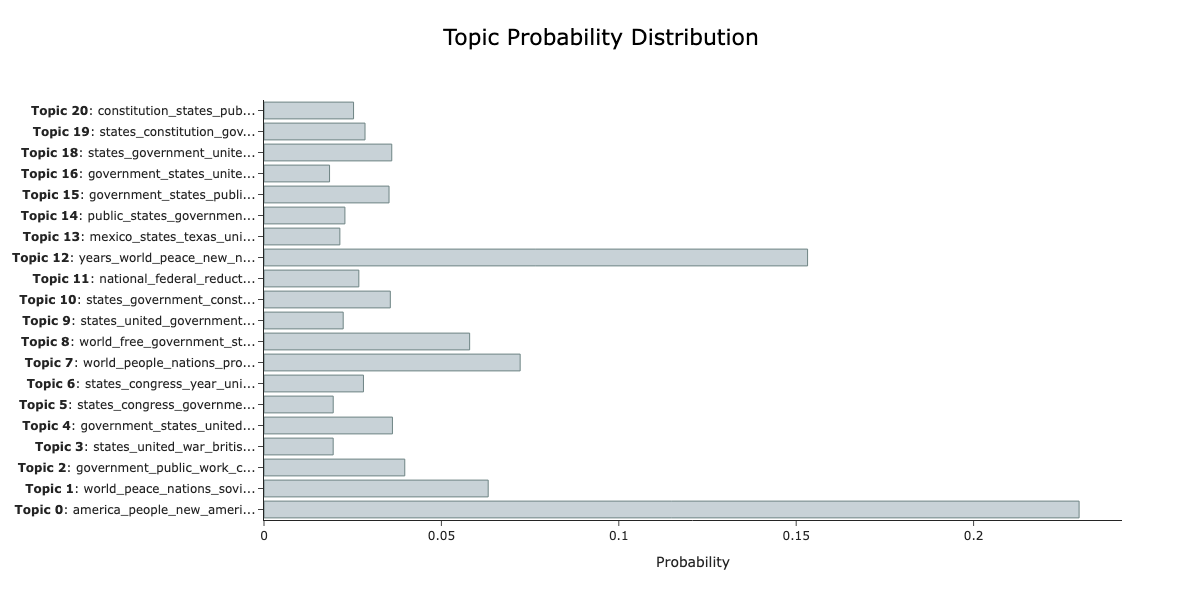

In [14]:
# output the topic distribution for the first speech
topic_distr, _ = topic_model.approximate_distribution(docs)
first_distribution = topic_distr[0] 
fig = topic_model.visualize_distribution(first_distribution,
                                         title="Topic Probability Distribution")

fig.write_html("outputs/topic_probability_distribution.html")
fig.show()

The following code generates an Intertopic Distance Map to help interpret the relationships between topics learned by the BERTopic model. The command `topic_model.visualize_topics()` creates an interactive plot showing how topics are positioned relative to each other in a reduced 2-dimensional space.

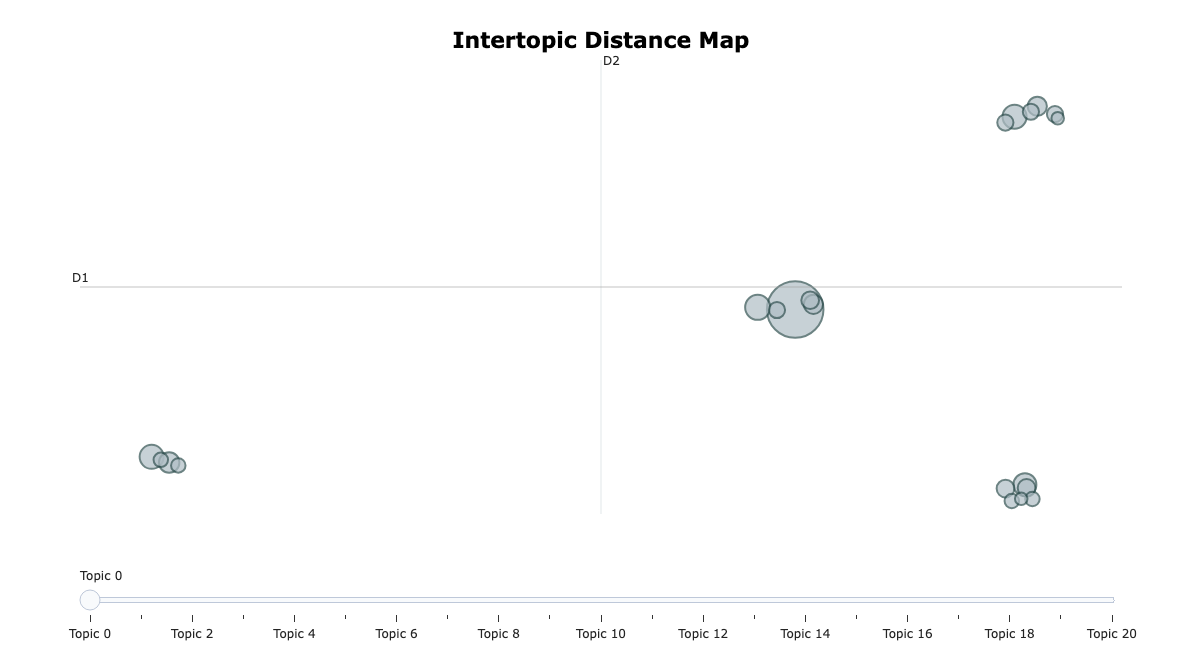

In [15]:
# run this cell to visualize the topics
topic_model.visualize_topics().write_html("outputs/intertopic_map.html")
topic_model.visualize_topics()